<a href="https://colab.research.google.com/github/AyeshaThapa/Projects/blob/main/inventory_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")


In [3]:
import os
print(os.listdir('/content/drive/My Drive/Colab Notebooks/'))
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/ecommerce_furniture_dataset_2024.csv')

['lefthanded.csv', 'deathdistribution.tsv', 'mte.fr.pdf', 'retail_sales.csv', 'Level 1 Task (1).ipynb', 'menu.csv', 'Level 1 Task.ipynb', 'L2.ipynb', 'Untitled1.ipynb', 'user_reviews.csv ', 'wine_qt.csv', 'twitter_data.csv', 'apps_data.csv', 'sentimentanalysis1.ipynb', 'Copy of sentimentanalysis1.ipynb', 'FraudDetection2.ipynb', 'WineQT.ipynb', 'McD report.ipynb', 'Untitled0.ipynb', 'Untitled2.ipynb', 'Untitled3.ipynb', 'E-commerce Furniture Dataset 2024  (  ML _ FA _ DA projects ).pdf', 'IBM HR Analytics Employee Attrition & Performance_ ML _ FA _ DA projects.pdf', 'drugs_side_effects_drugs_com.csv', 'Untitled4.ipynb', 'life_expectancy_data.csv', 'ocd_patients_dataset.csv', 'hr_employee_attrition.csv.gsheet', 'hr_employee_attrition.csv', 'Untitled6.ipynb', 'Inventory Data Analysis  _ (Finance Analyst)-20260108T145058Z-1-001.zip', 'ecommerce_furniture_dataset_2024.csv', 'ecomm.ipynb', 'Life expectancy.proj', 'OCD patients.ipynb', 'inventory analysis.ipynb']


In [4]:
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   productTitle   2000 non-null   object
 1   originalPrice  487 non-null    object
 2   price          2000 non-null   object
 3   sold           2000 non-null   int64 
 4   tagText        1997 non-null   object
dtypes: int64(1), object(4)
memory usage: 78.3+ KB


np.int64(94)

In [5]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
df.describe()


,sold
count,470.00000
mean,78.12766
std,519.04085
min,0.00000
25%,4.00000
50%,10.00000
75%,28.75000
max,10000.00000


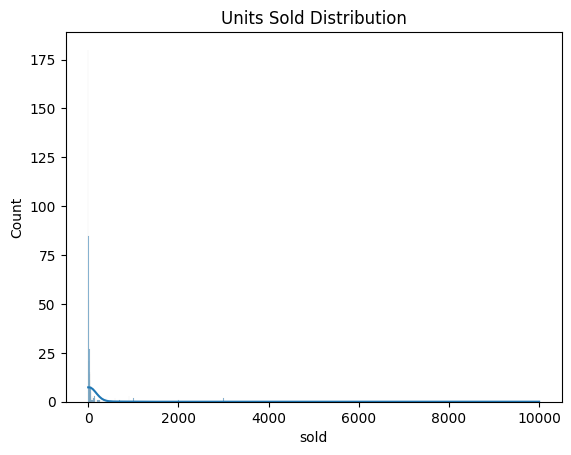

In [7]:
sns.histplot(df['sold'], kde=True)
plt.title("Units Sold Distribution")
plt.show()

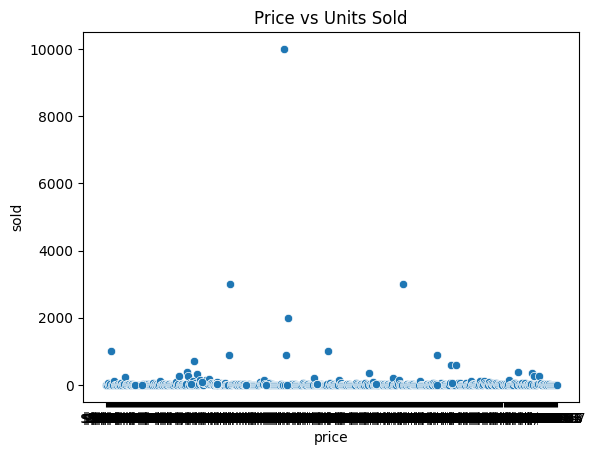

In [11]:
sns.scatterplot(x='price', y='sold', data=df)
plt.title("Price vs Units Sold")
plt.show()

In [13]:
df['DemandCategory'] = np.where(
    df['sold'] > df['sold'].mean(),
    'High',
    'Low'
)

df['DemandCategory'].value_counts()

,count
DemandCategory,
Low,426
High,44


In [22]:

if df['price'].dtype == 'object':
    df['price'] = df['price'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
    df['price'] = pd.to_numeric(df['price'])
if df['originalPrice'].dtype == 'object':
    df['originalPrice'] = df['originalPrice'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
    df['originalPrice'] = pd.to_numeric(df['originalPrice'])

df['AnnualValue'] = df['sold'] * df['price']

df = df.sort_values(by='AnnualValue', ascending=False)
df['CumulativeValue'] = df['AnnualValue'].cumsum()
df['CumulativePercentage'] = df['CumulativeValue'] / df['AnnualValue'].sum() * 100

def abc_classification(value):
    if value <= 70:
        return 'A'
    elif value <= 90:
        return 'B'
    else:
        return 'C'

df['ABC_Class'] = df['CumulativePercentage'].apply(abc_classification)
df['ABC_Class'].value_counts()

,count
ABC_Class,
C,316
B,99
A,55


In [23]:
df['InventoryTurnover'] = df['sold'] / df['price']
df[['productTitle', 'InventoryTurnover']].head()

,productTitle,InventoryTurnover
1008,335,814.332248
696,251,114.898506
1391,251,136.736554
1016,270,13.497301
1281,147,2.318271


In [24]:

if 'DailyDemand' not in df.columns:
    df['DailyDemand'] = df['sold'].mean() / 30

if 'LeadTime' not in df.columns:
    df['LeadTime'] = 7


if 'SafetyStock' not in df.columns:
    df['SafetyStock'] = df['sold'].std() * 0.5

if 'ProductID' not in df.columns:
    df['ProductID'] = df['productTitle']

df['ReorderPoint'] = (df['DailyDemand'] * df['LeadTime']) + df['SafetyStock']
df[['ProductID', 'ReorderPoint']].head()

,ProductID,ReorderPoint
1008,335,277.750212
696,251,277.750212
1391,251,277.750212
1016,270,277.750212
1281,147,277.750212


In [33]:
le = LabelEncoder()

# Iterate over all columns in the DataFrame
for col in df.columns:
    # If a column is of object dtype, apply LabelEncoder
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [25]:
X = df.drop('sold', axis=1)
y = df['sold']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [41]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [39]:
y_pred = model.predict(X_test)

In [37]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 18421.61738915042
R2 Score: 0.9826231134997598


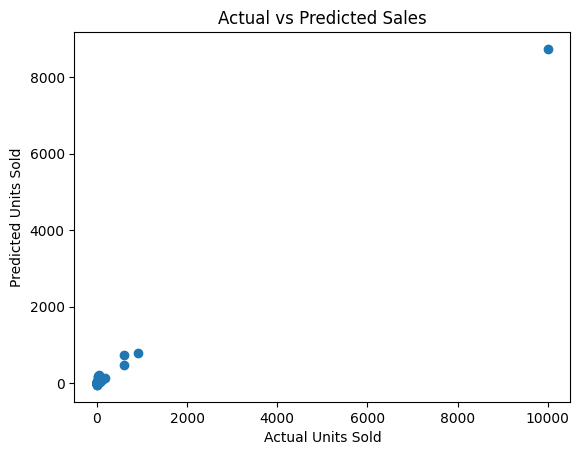

In [38]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Actual vs Predicted Sales")
plt.show()
